In [54]:
# rewriting non-linears layers to sort this problem to resolved this model not learning anything...
from helper_function import plot_decision_boundary, accuracy_fn
import torch
from torch import nn
import torch.optim as optim
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


# data
n_samples = 1000

x, y = make_circles(n_samples, noise=0.03, random_state=2026)
x, y = torch.tensor(x, dtype=torch.float), torch.tensor(y, dtype=torch.float)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2026)

# writing the model

class Circles_V3(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(in_features=2, out_features=10)
        self.layer2 = nn.Linear(in_features=10, out_features=10)
        self.layer3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU()

    def forward(self, x:torch.Tensor) -> torch.Tensor:
        z = self.relu(self.layer1(x))
        z = self.relu(self.layer2(z))
        z = self.layer3(z)
        return z
    
# defining model and writing manual seed

torch.manual_seed(2026)

model_v3 = Circles_V3()
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(params=model_v3.parameters(), lr=0.1)

# training loop

epochs = 1000

for epoch in range(epochs):
    model_v3.train()
    y_logits = model_v3(x_train).squeeze()
    y_preds = torch.round(torch.sigmoid(y_logits))
    acc_train = accuracy_fn(y_train, y_preds)
    loss = loss_fn(y_logits, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_v3.eval()
    with torch.inference_mode():
        test_logits = model_v3(x_test).squeeze()
        test_preds = torch.round(torch.sigmoid(test_logits))
        acc_test = accuracy_fn(y_test, test_preds)
        loss_test = loss_fn(test_logits, y_test)


    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | loss_train:{loss} | acc_train: {acc_train:.2f}% | loss_test: {loss_test} | acc_test: {acc_test:.2f}%")   


    

Epoch: 0 | loss_train:0.6972037553787231 | acc_train: 50.62% | loss_test: 0.7028853893280029 | acc_test: 47.50%
Epoch: 10 | loss_train:0.6949217319488525 | acc_train: 50.62% | loss_test: 0.6991885900497437 | acc_test: 47.50%
Epoch: 20 | loss_train:0.6937969923019409 | acc_train: 50.62% | loss_test: 0.6970707178115845 | acc_test: 47.50%
Epoch: 30 | loss_train:0.693208634853363 | acc_train: 50.62% | loss_test: 0.6957917809486389 | acc_test: 47.50%
Epoch: 40 | loss_train:0.6928674578666687 | acc_train: 50.62% | loss_test: 0.6949840784072876 | acc_test: 47.50%
Epoch: 50 | loss_train:0.6926420331001282 | acc_train: 50.62% | loss_test: 0.6944449543952942 | acc_test: 47.50%
Epoch: 60 | loss_train:0.6924691796302795 | acc_train: 53.62% | loss_test: 0.6940653920173645 | acc_test: 52.50%
Epoch: 70 | loss_train:0.692318856716156 | acc_train: 54.87% | loss_test: 0.6937820315361023 | acc_test: 47.50%
Epoch: 80 | loss_train:0.6921757459640503 | acc_train: 53.37% | loss_test: 0.6935621500015259 | acc

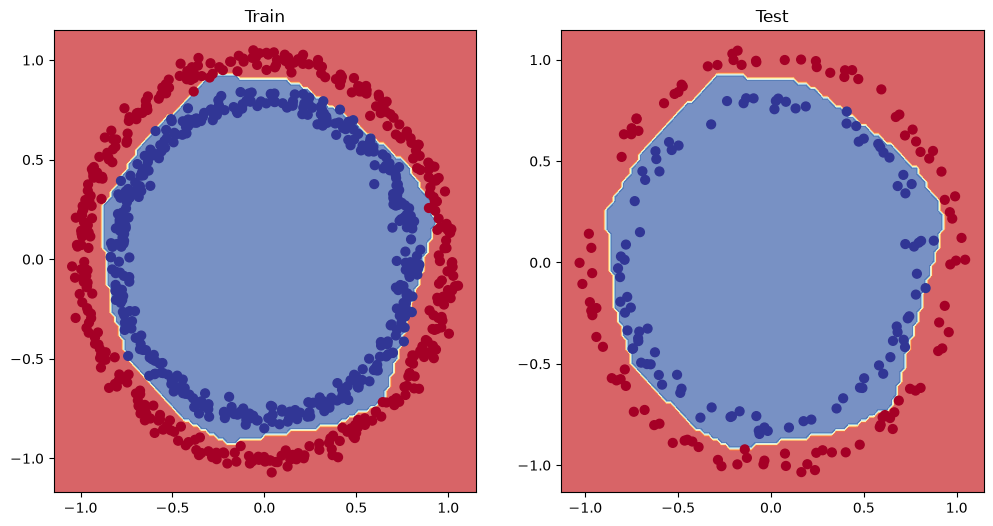

In [55]:
plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_v3, x_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_v3, x_test, y_test)